# Commande RST d'un double intégrateur


Le but de ce notebook est de caluler et de simuler un controleur RST agissant sur un modèle d'une balle sur poutre  

In [1]:
from Models.BallBeam import ballbeam_config
from Models.BallBeam.StateSpace import LinearStateSpaceModel
from Models.BallBeam.TransferFunctions import TransferFunctionModel

from Simulation.simulation import TFSimulator
from Simulation.simulation import HybridSim

from Simulation.runners import *

from Metrics_Plotting.SimLog import SimLog
from Metrics_Plotting.Plotting import Plotting

from Control.DiscretePID import DiscretePID
from Control.RSTController import RSTController

from Utils import computeRST
from Utils import utils

import numpy as np
import control as ct
import matplotlib.pyplot as plt

%matplotlib inline

Configuration de la simulation:


T est le temps total de simulation et dt est le temps d'échantillonage du correcteur

In [2]:
ballbeam_config.T=6
ballbeam_config.dt=0.05

In [3]:
X_0=np.array([[0],[0]]) ## état initial attention la syntaxe
double_int=TransferFunctionModel(ballbeam_config) ## instance de TransferFunctionModel
Double_int_sim=TFSimulator(double_int.Tf_dis,X_0) ## Double_int_sim est le simulateur de fonctions de transfert discrètes 
A=double_int.Tf_dis.den_list[0][0] ## extraction du numérateur, attention la syntaxe
B=double_int.Tf_dis.num_list[0][0] ## extraction du dénominateur 


In [4]:
### affichage 
print(double_int.Tf_cont)
print(double_int.Tf_dis)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.21
  ----
  s^2
<TransferFunction>: sys[0]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0002625 z + 0.0002625
  -----------------------
       z^2 - 2 z + 1


Fonction de transfert désirée 

Ici, on veut que le modèle agisse comme un second ordre.

 On commence par spécifier son dénominateur en dans le domaine continu, puis on discrétise les poles, $z_p=e^{s_pT_s}$

In [5]:
omega0=2.2
omega_carr=omega0*omega0
zeta=0.7

Am_s=[(1/(omega_carr)),((2.0*zeta)/omega0),1.0]
Am_d=np.poly(np.exp(np.roots(Am_s)*ballbeam_config.dt))

Bm=sum(Am_d) ## méthode pour assurer un gain unitaire constant Am(1)

Tf_des=ct.tf(Bm,Am_d,ballbeam_config.dt)


In [6]:
### affichage
print(Tf_des)
print("s poles:", np.roots(Am_s))
print("z poles:", np.roots(Am_d))
print("radius:", np.abs(np.roots(Am_d)))
print(Tf_des.dcgain())

<TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

          0.0112
  ----------------------
  z^2 - 1.846 z + 0.8573
s poles: [-1.54+1.57111425j -1.54-1.57111425j]
z poles: [0.92303449+0.07265915j 0.92303449-0.07265915j]
radius: [0.92588985 0.92588985]
1.0


In [7]:
## réponse inditielle de la fonction de transfert calculée par la librairie
t = np.arange( 0,ballbeam_config.T,ballbeam_config.dt)
_, y_lib = ct.step_response(Tf_des, t)


In [ ]:
## polynome de l'observateur, ne change pas la réponse iditielle mais modifie celle du rejet des perturbations
A0=[1,-0.9]

Synthèse du correcteur RST:
Pour inclure le polynome A0 il faut l'inclure dans la méthode en faisant np.polymul(Am_d,A0), True/False détermine la présence ou non de l'effet intégral $(1-z^-1)S'=S$.

In [28]:
S,R,T,H_cl=computeRST.Compute_Denominator_Matching_RST(Am_d, double_int.Tf_dis,True,A0)
#S,R,T,H_cl=computeRST.Compute_Denominator_Matching_RST(Am_d, double_int.Tf_dis,True,A0)
#S,R,T,H_cl=computeRST.Compute_Denominator_Matching_RST(np.polymul(Am_d,A0), double_int.Tf_dis,False,A0)



--- RST synthesis complete ---
S: [ 0.92120607 -0.92120607]
R: [ 300.16733849 -576.17022471  276.21627751]
T: [0.21339128]

Exact closed-loop transfer function enforced by R,S,T:
Numerator coefficients: [5.60152122e-05 5.60152122e-05]
Denominator coefficients: [ 1.         -2.83606898  2.68488031 -0.8486993 ]
<TransferFunction>: sys[32]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

       5.602e-05 z + 5.602e-05
  ----------------------------------
  z^3 - 2.836 z^2 + 2.685 z - 0.8487
Closed-loop DC gain: 1.000000000001982
Poles of the closed loop transfer function
z poles: [0.99      +0.j         0.92303449+0.07265915j 0.92303449-0.07265915j]
radius: [0.99       0.92588985 0.92588985]


Plusieures données sont affichées, les plus importates sont, les polynomes R,S et T, la fonction de transfert reconstruite et le gain en régime permanant (Closed-loop DC gain)

### Simulation
On crée une instance du controleur RST initialisé avec les polynomes R,S,T et on utilise le simulateur discret. Le premier True/False détermine la présence d'une perturbation constante au bout de la troisième seconde. Le deuxième active (si True) la saturation de l'actionneur.

In [29]:
rst_controller=RSTController(R,S,T)
logger_rst = SimLog()

reference=1.0
y_0=0.0

logger_rst= run_discrete_control(Double_int_sim,rst_controller,ballbeam_config,reference,y_0,logger_rst,True,True)
#logger_rst= run_discrete_control(Double_int_sim,rst_controller,ballbeam_config,reference,y_0,logger_rst,False,False)

Création de la fonction de transfert perturbation/sortie $Gd=\frac{BS}{AS+BR}$ et simulation de sa réponse inditielle

In [30]:
A = np.squeeze(A)
B = np.squeeze(B)
R_arr = np.squeeze(R.num[0][0])
S_arr = np.squeeze(S.num[0][0])

num = np.polymul(B, S_arr)
den = np.polyadd(np.polymul(A, S_arr),
                 np.polymul(B, R_arr))

Gd = ct.tf(num, den, ballbeam_config.dt)

print(Gd)
print("dcgain:", ct.dcgain(Gd))

t = np.asarray(t).flatten()

_, d = ct.step_response(Gd,t)



<TransferFunction>: sys[34]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.05

  0.0002418 z^2 + 8.182e-16 z - 0.0002418
  ---------------------------------------
    z^3 - 2.836 z^2 + 2.685 z - 0.8487
dcgain: 0.0


Affichage des trois réponses

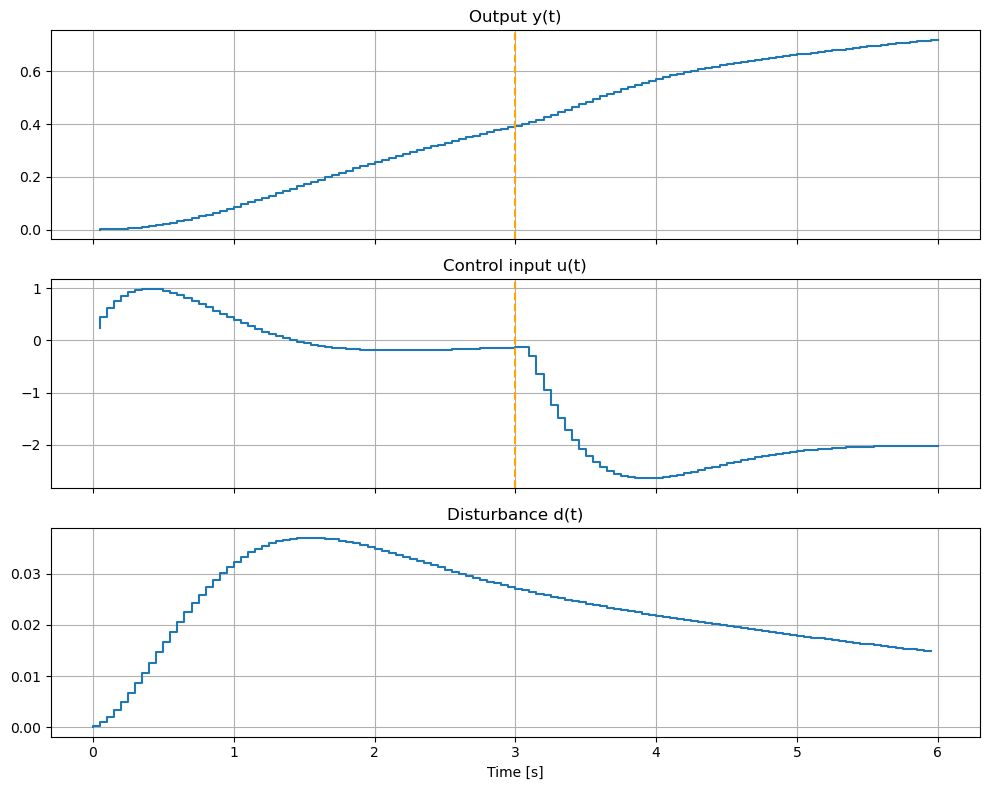

In [31]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].step(logger_rst.t_hist, logger_rst.y_hist)
ax[0].set_title("Output y(t)")
ax[0].grid()


ax[1].step(logger_rst.t_hist, logger_rst.u_hist)
ax[1].set_title("Control input u(t)")
ax[1].grid()

ax[1].legend


ax[2].step(t, d)
ax[2].set_title("Disturbance d(t)")
ax[2].grid()

ax[0].axvline(x=3, color='orange', linestyle='--',label='Disturbance')
ax[1].axvline(x=3, color='orange', linestyle='--',label='Disturbance')
plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()